## Step 1: Data Loading and Understanding
Loaded the Telco dataset (7,043 customers, 21 columns). Target variable: `Churn`.

In [81]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [82]:
df.shape

(7043, 21)

In [83]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [84]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [86]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Observation:** 73% of customers stayed and 27% left, so the data is imbalanced. TotalCharges has the wrong data type (text).

## Step 2: Data Preprocessing
Checked the data for missing values, duplicates, wrong data types and unnecessary columns, and cleaned it.

In [87]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [88]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [89]:
df.duplicated().sum()

np.int64(0)

In [90]:
df[df["TotalCharges"].str.strip() == ""][["customerID", "tenure", "TotalCharges"]]

,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,
3331,7644-OMVMY,0,
3826,3213-VVOLG,0,
4380,2520-SGTTA,0,
5218,2923-ARZLG,0,
6670,4075-WKNIU,0,


In [91]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isnull().sum()

np.int64(11)

In [92]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df["TotalCharges"].isnull().sum()

np.int64(0)

In [93]:
df = df.drop("customerID", axis=1)
df.shape

(7043, 20)

In [94]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [95]:
for col in df.select_dtypes(include="object").columns:
    print(col, df[col].unique())

gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


**Observation:** No missing values or duplicates. `TotalCharges` had 11 blank values (customers with tenure 0), so I converted it to numbers and filled them with 0. Dropped `customerID` (no predictive value). Converted `Churn` to 0/1.

## Step 3: Exploratory Data Analysis
Explored how churn relates to the main customer characteristics using tables and charts.

In [96]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
0,73.463013
1,26.536987


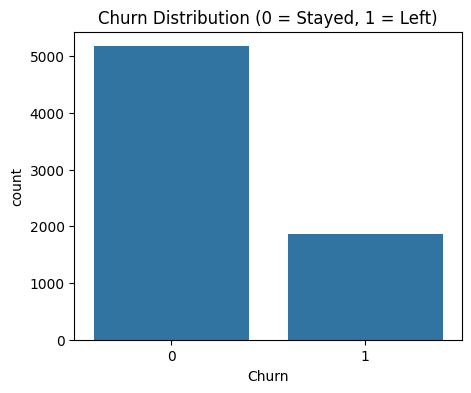

In [97]:
plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution (0 = Stayed, 1 = Left)")
plt.show()

In [98]:
df.groupby("Contract")["Churn"].mean() * 100

,Churn
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858


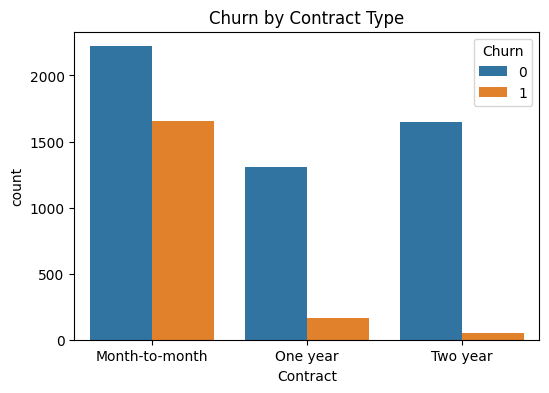

In [99]:
plt.figure(figsize=(6,4))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.show()

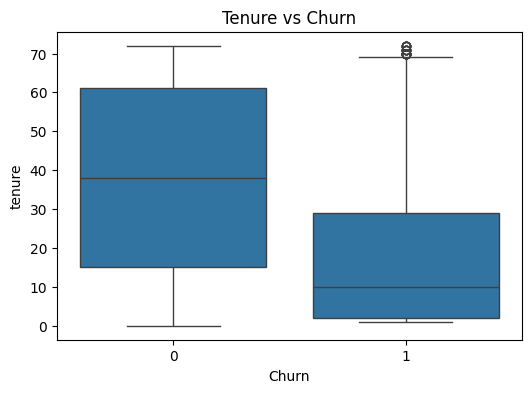

In [100]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

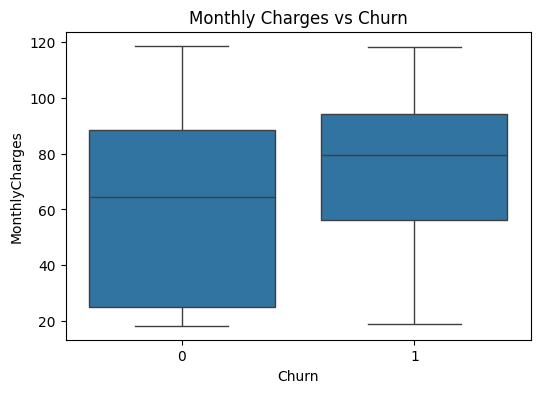

In [101]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [102]:
df.groupby("InternetService")["Churn"].mean() * 100

,Churn
InternetService,
DSL,18.959108
Fiber optic,41.892765
No,7.404980


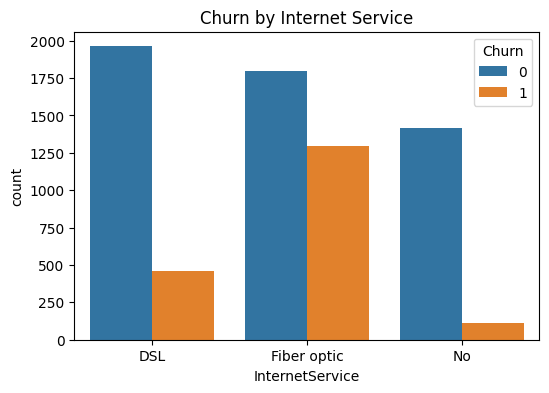

In [103]:
plt.figure(figsize=(6,4))
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Churn by Internet Service")
plt.show()

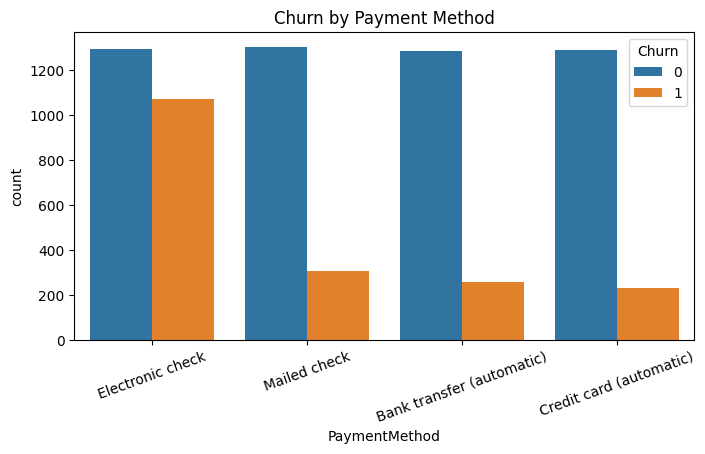

In [104]:
plt.figure(figsize=(8,4))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=20)
plt.title("Churn by Payment Method")
plt.show()

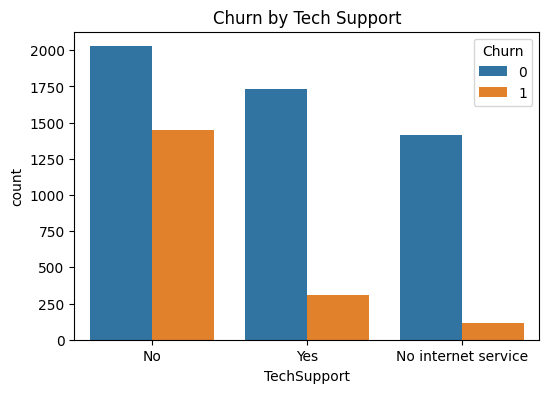

In [105]:
plt.figure(figsize=(6,4))
sns.countplot(x="TechSupport", hue="Churn", data=df)
plt.title("Churn by Tech Support")
plt.show()

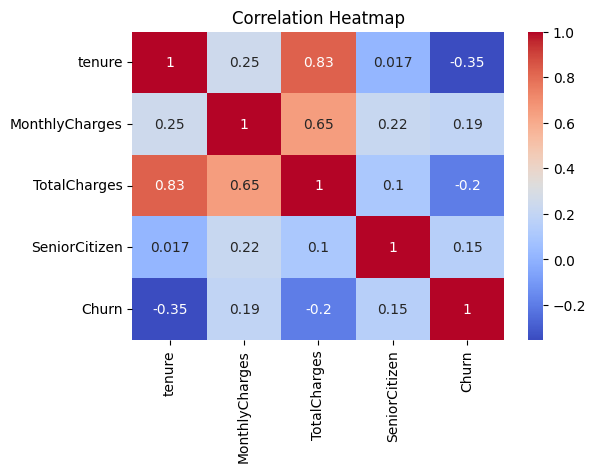

In [106]:
plt.figure(figsize=(6,4))
sns.heatmap(df[["tenure","MonthlyCharges","TotalCharges","SeniorCitizen","Churn"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Observation:** Churn is highest for month-to-month contracts (about 43%), short tenure, fiber optic internet (about 42%), high monthly charges, electronic check payment, and no tech support. Longer contracts and longer tenure strongly reduce churn.

## Step 4: Feature Engineering and Encoding
Created a new feature, separated the inputs (X) from the target (y), and converted text columns to numbers.

In [107]:
df["AvgChargesPerMonth"] = df["TotalCharges"] / df["tenure"].replace(0, 1)
df[["tenure","TotalCharges","AvgChargesPerMonth"]].head()

,tenure,TotalCharges,AvgChargesPerMonth
0,1,29.85,29.850000
1,34,1889.50,55.573529
2,2,108.15,54.075000
3,45,1840.75,40.905556
4,2,151.65,75.825000


In [108]:
X = df.drop("Churn", axis=1)
y = df["Churn"]
print(X.shape, y.shape)

(7043, 20) (7043,)


In [109]:
X = pd.get_dummies(X, drop_first=True, dtype=int)
print(X.shape)
X.head()

(7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AvgChargesPerMonth,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,29.850000,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,55.573529,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,54.075000,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,40.905556,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,75.825000,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [110]:
X.dtypes.value_counts()

,count
int64,28
float64,3


**Observation:** Added `AvgChargesPerMonth` (TotalCharges ÷ tenure). One-hot encoding turned all text columns into 0/1 columns. X now has 31 numeric input features and y is `Churn`.

## Step 5: Training and Testing
Split the data into training and testing sets and trained two classification models.

In [111]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)
print("Churn rate in train:", y_train.mean())
print("Churn rate in test :", y_test.mean())

Training set: (5634, 31)
Testing set : (1409, 31)
Churn rate in train: 0.2653532126375577
Churn rate in test : 0.2654364797728886


In [112]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [113]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
print("Logistic Regression trained")

Logistic Regression trained


In [114]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest trained")

Random Forest trained


**Observation:** 80% of the data (5,634 customers) is used for training and 20% (1,409) for testing, with the same churn ratio in both. Logistic Regression was trained on scaled data. Random Forest does not need scaling.

## Step 6: Model Evaluation
Tested both models on the unseen test data using accuracy, precision, recall, F1-score and the confusion matrix.

In [115]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

def evaluate(model, X_data, name):
    pred = model.predict(X_data)
    print("=====", name, "=====")
    print("Accuracy :", round(accuracy_score(y_test, pred), 4))
    print("Precision:", round(precision_score(y_test, pred), 4))
    print("Recall   :", round(recall_score(y_test, pred), 4))
    print("F1-Score :", round(f1_score(y_test, pred), 4))
    print()
    print(classification_report(y_test, pred, target_names=["No Churn", "Churn"]))
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Churn","Churn"], yticklabels=["No Churn","Churn"])
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(name)
    plt.show()

===== Logistic Regression =====
Accuracy : 0.8077
Precision: 0.6604
Recall   : 0.5668
F1-Score : 0.6101

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



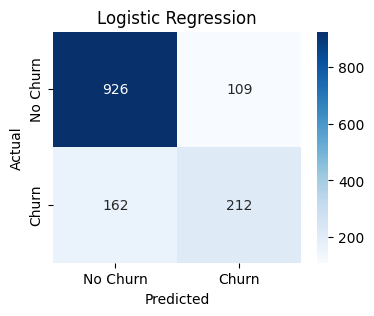

In [116]:
evaluate(lr_model, X_test_scaled, "Logistic Regression")

===== Random Forest =====
Accuracy : 0.7885
Precision: 0.6284
Recall   : 0.4973
F1-Score : 0.5552

              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



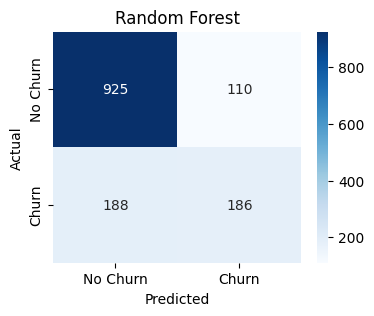

In [117]:
evaluate(rf_model, X_test, "Random Forest")

**Observation:** Logistic Regression performed better on every metric (accuracy 80.8%, precision 66.0%, recall 56.7%, F1 0.61) than Random Forest (accuracy 78.9%, recall 49.7%, F1 0.56). It catches more real churners, so it is selected as the final model.

## Step 7: Application / Prediction
Used the final model (Logistic Regression) to predict churn for sample customers.

In [118]:
def predict_customer(customer):
    # 1. Turn the customer dictionary into a one-row table
    c = pd.DataFrame([customer])

    # 2. Create the same engineered feature we used in training
    c["AvgChargesPerMonth"] = c["TotalCharges"] / c["tenure"].replace(0, 1)

    # 3. Encode the same way as training, then match the training columns exactly
    c_encoded = pd.get_dummies(c, dtype=int)
    c_encoded = c_encoded.reindex(columns=X.columns, fill_value=0)

    # 4. Scale using the SAME scaler fitted on training data
    c_scaled = scaler.transform(c_encoded)

    # 5. Predict
    pred = lr_model.predict(c_scaled)[0]
    prob = lr_model.predict_proba(c_scaled)[0][1]

    print("Prediction :", "CHURN" if pred == 1 else "NO CHURN")
    print("Churn probability:", round(prob * 100, 1), "%")

In [119]:
customer_1 = {
    "gender": "Female", "SeniorCitizen": 0, "Partner": "No", "Dependents": "No",
    "tenure": 2, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "No",
    "StreamingMovies": "No", "Contract": "Month-to-month", "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check", "MonthlyCharges": 85.0, "TotalCharges": 170.0
}
predict_customer(customer_1)

Prediction : CHURN
Churn probability: 58.8 %


In [120]:
customer_2 = {
    "gender": "Male", "SeniorCitizen": 0, "Partner": "Yes", "Dependents": "Yes",
    "tenure": 60, "PhoneService": "Yes", "MultipleLines": "Yes",
    "InternetService": "DSL", "OnlineSecurity": "Yes", "OnlineBackup": "Yes",
    "DeviceProtection": "Yes", "TechSupport": "Yes", "StreamingTV": "No",
    "StreamingMovies": "No", "Contract": "Two year", "PaperlessBilling": "No",
    "PaymentMethod": "Bank transfer (automatic)", "MonthlyCharges": 65.0, "TotalCharges": 3900.0
}
predict_customer(customer_2)

Prediction : NO CHURN
Churn probability: 0.7 %


**Observation:** The function takes raw customer details, applies the same preprocessing as training, and returns Churn / No Churn with a probability. Customer 1 (new, month-to-month, fiber, no support) is predicted Churn. Customer 2 (60 months, two-year contract) is predicted No Churn. Customer 3 is predicted No Churn but is close to the cutoff.